# Erdos-Renyi Random Graph Diagnostics

Explore `data/graphs/enes_all/ciuo/_random_graphs/erdos_renyi` to understand why persistence diagram computation is slow.

In [1]:
from pathlib import Path
import time
import tracemalloc

import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, str(Path.cwd().parent))

import src.topology as topo
from scripts import gc, pl

pd.set_option("display.max_columns", 50)

DATA_DIR = Path("../data/graphs/enes_all/ciuo/_random_graphs/erdos_renyi")
OUTPUT_DIR = Path("../notebooks/outputs/erdos_renyi")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR

PosixPath('../data/graphs/enes_all/ciuo/_random_graphs/erdos_renyi')

## 1. Locate and enumerate Erdos-Renyi random graph files

List available files, parse the filename into `weight_function` and `i`, and build an index table.

In [2]:
def parse_filename(path: Path) -> dict:
    name = path.stem
    if not name.startswith("_"):
        return {"file": path.name, "weight_function": None, "i": None}
    stem = name[1:]
    parts = stem.split("_")
    if parts and parts[-1].isdigit():
        i = int(parts[-1])
        weight_function = "_".join(parts[:-1])
    else:
        i = None
        weight_function = stem
    return {"file": path.name, "weight_function": weight_function, "i": i}

files = sorted(DATA_DIR.glob("*.gexf"))
index_rows = [parse_filename(path) for path in files]
index_df = pd.DataFrame(index_rows)

print(f"Found {len(files)} files in {DATA_DIR}")
index_df.head(10)

Found 33 files in ../data/graphs/enes_all/ciuo/_random_graphs/erdos_renyi


,file,weight_function,i
0,_hidalgo_0.gexf,hidalgo,0
1,_hidalgo_1.gexf,hidalgo,1
2,_hidalgo_10.gexf,hidalgo,10
3,_hidalgo_12.gexf,hidalgo,12
4,_hidalgo_14.gexf,hidalgo,14
5,_hidalgo_15.gexf,hidalgo,15
6,_hidalgo_17.gexf,hidalgo,17
7,_hidalgo_18.gexf,hidalgo,18
8,_hidalgo_19.gexf,hidalgo,19
9,_hidalgo_2.gexf,hidalgo,2


## 2. Load a sample graph and summarize structure

Load one GEXF graph and report basic statistics.

In [3]:
sample_path = files[0] if files else None
sample_path

PosixPath('../data/graphs/enes_all/ciuo/_random_graphs/erdos_renyi/_hidalgo_0.gexf')

In [4]:
def summarize_graph(graph: nx.Graph) -> pd.Series:
    node_count = graph.number_of_nodes()
    edge_count = graph.number_of_edges()
    density = nx.density(graph)
    components = nx.number_connected_components(graph) if node_count else 0
    degrees = np.array([deg for _, deg in graph.degree()])
    weight_values = np.array([
        data.get("weight", 0.0) for _, _, data in graph.edges(data=True)
    ])
    return pd.Series(
        {
            "nodes": node_count,
            "edges": edge_count,
            "density": density,
            "components": components,
            "deg_min": degrees.min() if degrees.size else 0,
            "deg_mean": degrees.mean() if degrees.size else 0.0,
            "deg_max": degrees.max() if degrees.size else 0,
            "weight_min": weight_values.min() if weight_values.size else 0.0,
            "weight_mean": weight_values.mean() if weight_values.size else 0.0,
            "weight_max": weight_values.max() if weight_values.size else 0.0,
        }
    )

if sample_path is None:
    print("No GEXF files found.")
else:
    sample_graph = nx.read_gexf(sample_path, node_type=int)
    summary = summarize_graph(sample_graph)

summary

nodes          4.720000e+02
edges          3.354900e+04
density        3.018191e-01
components     1.000000e+00
deg_min        1.000000e+02
deg_mean       1.421568e+02
deg_max        1.800000e+02
weight_min     1.637869e-08
weight_mean    4.866472e-02
weight_max     9.971358e-01
dtype: float64

## 3. Batch persistence diagram timing and profiling

Compute persistence diagrams for a subset, capturing wall time and peak memory.

In [6]:
def compute_diagram(graph: nx.Graph, topo_method: str = "disparity_filtration"):
    distance_matrix = gc.compute_distance_matrix(graph, method=topo_method)
    diagrams = topo.compute_persistence(
        distance_matrix,
        maxdim=1,
        thresh=50,
        coeff=2,
    )
    return diagrams

sample_size = min(5, len(files))
subset = files[:sample_size]

records = []
for path in subset:
    graph = nx.read_gexf(path, node_type=int)
    tracemalloc.start()
    start = time.perf_counter()
    status = "ok"
    diagrams = None
    error = None
    try:
        diagrams = compute_diagram(graph, topo_method="disparity_filtration")
    except Exception as exc:
        status = "error"
        error = repr(exc)
    elapsed = time.perf_counter() - start
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    records.append(
        {
            "file": path.name,
            "elapsed_s": elapsed,
            "peak_mb": peak / (1024 * 1024),
            "status": status,
            "error": error,
            "h0_count": len(diagrams[0]) if diagrams else None,
            "h1_count": len(diagrams[1]) if diagrams and len(diagrams) > 1 else None,
        }
    )

timing_df = pd.DataFrame(records).sort_values("elapsed_s", ascending=False)
timing_df

,file,elapsed_s,peak_mb,status,error,h0_count,h1_count
0,_hidalgo_0.gexf,0.681400,24.000544,ok,None,472,395
1,_hidalgo_1.gexf,0.668383,24.000528,ok,None,472,382
2,_hidalgo_10.gexf,0.660046,24.009287,ok,None,472,376
3,_hidalgo_12.gexf,0.644133,24.010246,ok,None,472,394
4,_hidalgo_14.gexf,0.629039,24.000422,ok,None,472,373


## 4. Compare parameter distributions across graphs

Inspect filename-derived parameters to spot outliers that may correlate with slow runs.

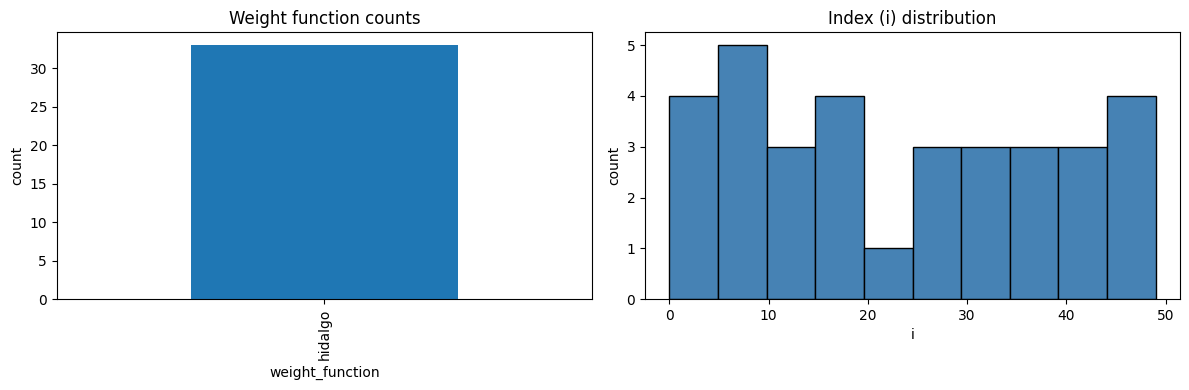

In [ ]:
if index_df.empty:
    print("No files to plot.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    index_df["weight_function"].value_counts().plot(
        kind="bar", ax=axes[0], title="Weight function counts"
    )
    axes[0].set_xlabel("weight_function")
    axes[0].set_ylabel("count")

    i_values = index_df["i"].dropna().astype(int)
    axes[1].hist(i_values, bins=10, color="steelblue", edgecolor="black")
    axes[1].set_title("Index (i) distribution")
    axes[1].set_xlabel("i")
    axes[1].set_ylabel("count")

    plt.tight_layout()
    plt.show()

## 5. Visualize persistence diagrams and compute $H_0/H_1$ summaries

Compare a fast vs slow case with diagram plots and summary statistics.

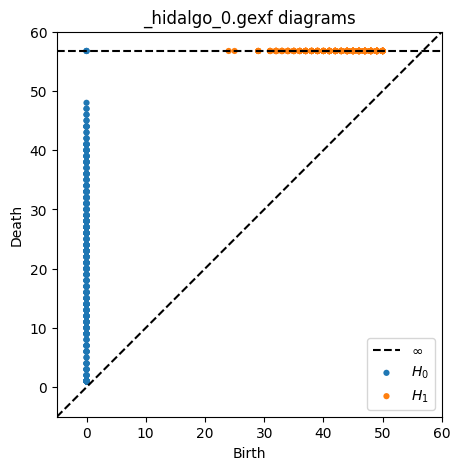

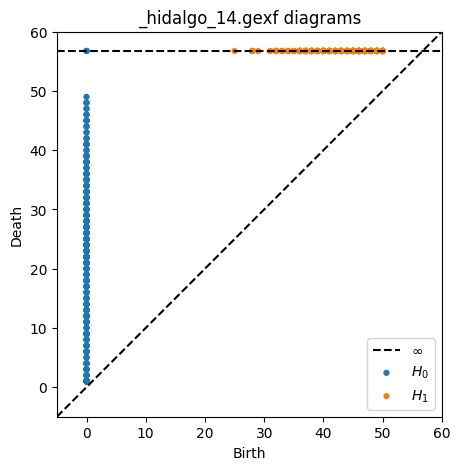

In [ ]:
def summarize_diagrams(diagrams) -> dict:
    summary = {}
    for dim, dgm in enumerate(diagrams):
        if len(dgm) == 0:
            summary[f"h{dim}_count"] = 0
            summary[f"h{dim}_max_persistence"] = 0.0
            summary[f"h{dim}_total_persistence"] = 0.0
            continue
        births = dgm[:, 0]
        deaths = dgm[:, 1]
        finite = np.isfinite(deaths)
        persistence = deaths[finite] - births[finite]
        summary[f"h{dim}_count"] = len(dgm)
        summary[f"h{dim}_max_persistence"] = persistence.max() if persistence.size else 0.0
        summary[f"h{dim}_total_persistence"] = persistence.sum() if persistence.size else 0.0
    return summary

if timing_df.empty:
    print("Run the timing cell first.")
else:
    ok_df = timing_df[timing_df["status"] == "ok"].copy()
    if ok_df.empty:
        print("No successful persistence computations yet.")
    else:
        slow_row = ok_df.iloc[0]
        fast_row = ok_df.iloc[-1]

        cases = [slow_row, fast_row]
        summaries = []
        for row in cases:
            path = DATA_DIR / row["file"]
            graph = nx.read_gexf(path, node_type=int)
            diagrams = compute_diagram(graph, topo_method="disparity_filtration")
            summaries.append({"file": row["file"], **summarize_diagrams(diagrams)})

            fig, ax = plt.subplots(1, 1, figsize=(6, 5))
            pl.plot_persistence_diagrams(diagrams, ax=ax, title=f"{row['file']} diagrams", save=False)
            plt.show()

        summary_df = pd.DataFrame(summaries)
        summary_df